## Imports

In [2]:
# Interactive plots
from ipywidgets import interact, FloatSlider, Layout
fs= lambda low,high,inc: FloatSlider(min=low,max=high,step=inc,continuous_update=False,
                                     layout=Layout(width='100%'))

import numpy as np
from matplotlib import pyplot as plt
pi = np.pi

# Change the default figure size
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['figure.dpi'] = 150

## Generate the Signal

In [3]:
# Signal parameters
sample_rate = 100
signal_duration = 100


def make_signal(signal_duration,frequency,noise):
    # Generate time vector and signal
    t = np.arange(0,signal_duration,1/sample_rate)
    signal = np.cos(2*pi*frequency*t)+noise*np.random.randn(t.shape[0])
    return t,signal

def plot_signal(signal_duration,frequency,noise):
    
    t,signal = make_signal(signal_duration,frequency,noise)
    
    # Plot and annotate
    plt.figure()
    plt.plot(t,signal)
    plt.xlabel('Time (s)')
    plt.ylabel('Acceleration (g)')
    plt.show()
    
interact(plot_signal,signal_duration=fs(1,10,.1),frequency=fs(1,10,.1),noise=fs(0,5,.1))

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='signal_duration', layout=La…

<function __main__.plot_signal(signal_duration, frequency, noise)>

## Compute the FFT

In [4]:
# Import FFT libraries
from scipy.fftpack import fft, fftfreq, fftshift

def compute_fft(t,signal):
    N=signal.shape[0]
    dt=1/sample_rate

    f_signal = 2.0/N *fft(signal)
    f = fftfreq(N, dt)

    f_signal = fftshift(f_signal)
    f = fftshift(f)
    
    return f,f_signal

def plot_fft(signal_duration,frequency,noise):
    
    t,signal = make_signal(signal_duration,frequency,noise)
    f,f_signal = compute_fft(t,signal)
    #t,signal_2 = make_signal(signal_duration,frequency+.2,noise)
    #f,f_signal = compute_fft(t,signal+signal_2)
    
    # Plot and annotate
    plt.figure()
    plt.plot(f, np.abs(f_signal),'.-')
    plt.grid()

    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Acceleration (g)')
    plt.xlim([0,10])
    plt.show()
    
    
interact(plot_fft,signal_duration=fs(1,50,.1),frequency=fs(0,10,.11),noise=fs(0,50,.1))



interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='signal_duration', layout=La…

<function __main__.plot_fft(signal_duration, frequency, noise)>

## Power Spectral Density

In [ ]:
# Import PSD library
from scipy.signal import welch
sample_rate = 100

def plot_psd(num_averages,frequency,noise,window_length):
    
    signal_duration = num_averages*window_length
    t,signal = make_signal(signal_duration,frequency,noise)
    f,f_signal = welch(signal,sample_rate,nperseg=window_length)
    
    # Plot and annotate
    plt.figure()
    plt.plot(f[2:-2], np.abs(f_signal[2:-2]))
    plt.grid()

    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Acceleration^2/Hz (g)')
    plt.show()
    
interact(plot_psd,num_averages=fs(1,20,1),frequency=fs(1,50,.11),noise=fs(0,50,.1),window_length=fs(10,10000,1))


interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='num_averages', layout=Layou…

<function __main__.plot_psd(num_averages, frequency, noise, window_length)>

## Filtering

In [11]:
from scipy.signal import firwin, lfilter, butter
from scipy.signal import welch

# Signal parameters
sample_rate = 1000
signal_duration = 10
frequencies = [150]

window_length=1024

def make_multitone_signal(noise):
    t = np.arange(0,signal_duration,1/sample_rate)
    signal = 0
    for frequency in frequencies:
        signal += np.cos(2*pi*frequency*t)
    signal += noise*np.random.randn(t.shape[0]) + .25
    return t,signal
    
def band_pass(signal,sample_rate,cutoffs,order):
    # Design the filter
    
    # FIR filter
    #b = firwin(int(order),np.asarray(cutoffs)/(sample_rate/2),pass_zero=False)
    #a = 1
    
    # IIR Filter
    [b,a] = butter(int(order),np.asarray(cutoffs)/(sample_rate/2),'bandpass')
    
    # Apply the filter
    filtered_signal = lfilter(b,a,signal)
    
    return filtered_signal, b, a
       
def plot_psd(noise,low_cutoff,high_cutoff,order):
    
    t,signal = make_multitone_signal(noise)
    filtered_signal, b,a = band_pass(signal,sample_rate,[low_cutoff,high_cutoff],order)
    
    f,f_signal = welch(filtered_signal,sample_rate,nperseg=window_length)
    
    # Plot and annotate
    # Original signal
    fig=plt.figure(figsize = [9,5])
    plt.subplot(3,1,1)
    plt.plot(t[0:400],signal[0:400])
    plt.ylabel('Acceleration (g)')
    
    # Filtered signal
    plt.plot(t[0:400],filtered_signal[0:400])
    plt.xlabel('Time (s)')
    plt.ylabel('Acceleration (g)')
    
    # Filter weights
    plt.subplot(3,1,2)
    plt.stem(b)
    plt.ylabel('Filter Weights')

    #PSD 
    plt.subplot(3,1,3)
    plt.semilogy(f[0:400], np.abs(f_signal[0:400]))
    plt.grid()
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Acceleration^2/Hz (g)')

    plt.show()

interact(plot_psd,noise=fs(0,5,.1),
         low_cutoff=fs(.1,sample_rate/2-1,.1),high_cutoff=fs(2,sample_rate/2-1,.1),order=fs(1,200,1))


interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='noise', layout=Layout(width…

<function __main__.plot_psd(noise, low_cutoff, high_cutoff, order)>

## Spectrogram


In [7]:
# Pulled from https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.spectrogram.html

from scipy import signal
from scipy.fftpack import fftshift
import matplotlib.pyplot as plt

# Generate Signal
sample_rate = 10e3
N = 1e5
amp = 2 * np.sqrt(2)
noise_amp = 1

time = np.arange(N) / float(sample_rate)

# Frequency modulated signal
mod = 2000*np.cos(2*np.pi*0.25*time)
carrier = amp * np.sin(2*np.pi*3e3*time + mod)

# Exponentially decreasing noise
noise = noise_amp*np.random.randn(len(time))
noise *= np.exp(-time/2)

# Steady tone
tone = 0.1*np.cos(2*pi*2e3*time)

# Sharp transient
transient = np.zeros(time.shape)
transient[int(len(time)/2)]=10

# Combine signals
x = carrier + noise + tone + transient


def plot_spectrogram(window_length):
    plt.figure()
    f, t, Sxx = signal.spectrogram(x, sample_rate, nperseg=int(window_length))
    plt.pcolormesh(t, f, np.log10(Sxx),cmap='jet')
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [sec]')
    plt.show()

interact(plot_spectrogram,window_length=fs(128,len(time)/16,1))


interactive(children=(FloatSlider(value=128.0, continuous_update=False, description='window_length', layout=La…

<function __main__.plot_spectrogram(window_length)>

Text(0, 0.5, 'Time (s)')

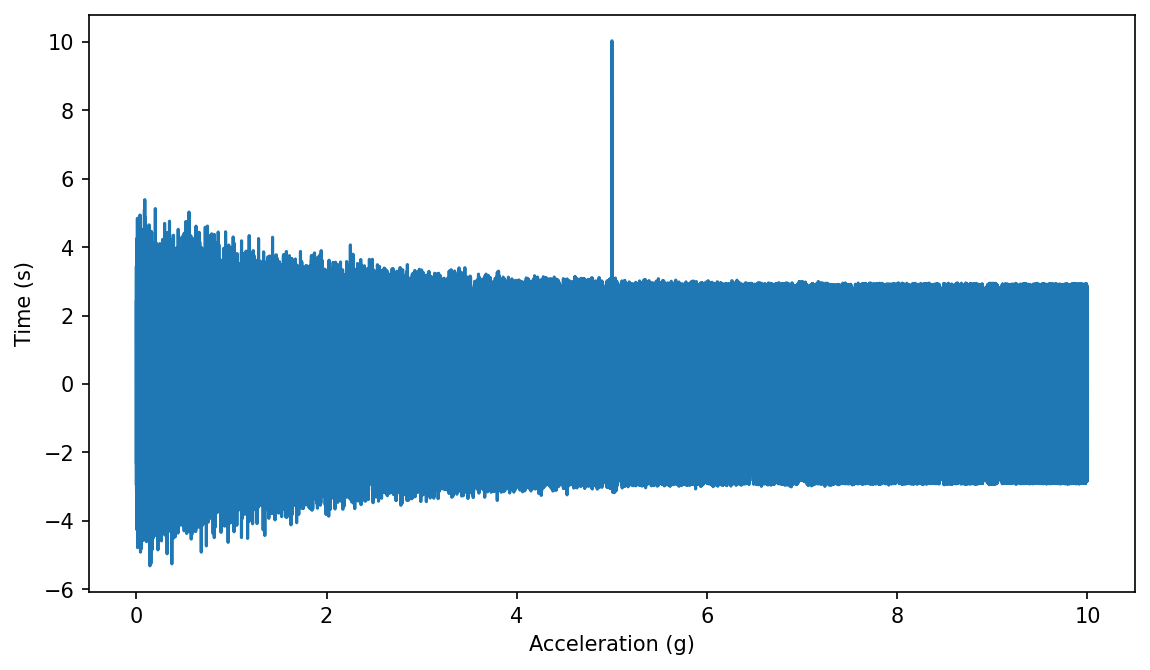

In [8]:
plt.plot(time,x)
plt.xlabel('Acceleration (g)')
plt.ylabel('Time (s)')

# Aliasing

In [19]:
# Import FFT libraries
from scipy.fftpack import fft, fftfreq, fftshift

signal_duration=2

def make_aliased_signal(frequency,noise,sample_rate):
    # Generate time vector and signal
    t = np.arange(0,signal_duration,1/sample_rate)
    signal = np.sin(2*pi*frequency*t)+noise*np.random.randn(t.shape[0])
    return t,signal

def compute_fft(dt,signal):
    N=signal.shape[0]

    f_signal = 2.0/N *fft(signal)
    f = fftfreq(N, dt)

    f_signal = fftshift(f_signal)
    f = fftshift(f)
    
    return f,f_signal

def up_sample(signal,factor):
    n = len(signal)
    up = np.zeros((factor*n),dtype=signal.dtype)
    up[::factor] = signal
    return up
    

def plot_fft(frequency,sample_rate_1,sample_rate_2,noise,guess_frequency):
    
    # Sample the signal at rate 1
    t_1,signal_1 = make_aliased_signal(frequency,noise,sample_rate_1)
    
    # Sample the signal at rate 2
    t_2,signal_2 = make_aliased_signal(frequency,noise,sample_rate_2)
    
    # Upsample the signals through zero insertion
    up_factor = 4
    signal_1_up=up_sample(signal_1,up_factor)
    signal_2_up=up_sample(signal_2,up_factor)
    
    # Compute the ffts
    f_1,f_signal_1 = compute_fft(1/sample_rate_1/up_factor,signal_1_up)
    f_2,f_signal_2 = compute_fft(1/sample_rate_2/up_factor,signal_2_up)
    
    # Generate the "guessed" signal
    t_guess,signal_guess = make_aliased_signal(guess_frequency,0,1000)
    
    # Plot and annotate
    plt.figure()
    plt.subplot(2,1,1)
    
    # Time series
    plt.plot(t_1,signal_1,'b.')
    plt.plot(t_2,signal_2,'r.')
    plt.plot(t_guess,signal_guess,'g-',linewidth=.5)
    plt.plot(t_guess,-signal_guess,'g--',linewidth=.5)
    plt.xlabel('Time (s)')
    plt.ylabel('Acc. (g)')
    
    # Fourier Domain
    plt.subplot(2,1,2)
    plt.plot(f_1, np.abs(f_signal_1),'b-')
    plt.plot(f_2, np.abs(f_signal_2),'r-')
    plt.grid()
    
    # Draw Nyquist
    plt.plot([-sample_rate_1/2,sample_rate_1/2],[0,0],'b^',markersize=20)
    plt.plot([-sample_rate_2/2,sample_rate_2/2],[0,0],'r^',markersize=20)
    
    # Draw Guess frequency
    plt.plot(guess_frequency,0,'gd')

    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Acc (g)')
    plt.show()
    
    
interact(plot_fft,frequency=fs(1,10,.25),
         sample_rate_1=fs(1,20,.1),sample_rate_2=fs(1,20,.1),noise=fs(0,50,.1),
         guess_frequency=fs(0,20,.25))

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='frequency', layout=Layout(w…

<function __main__.plot_fft(frequency, sample_rate_1, sample_rate_2, noise, guess_frequency)>